# Housing Price Predictor — Week 2 Project
**Author:** Debiprasad Samal

A complete linear regression project using scikit-learn.
- Compare SGDRegressor (Gradient Descent) vs LinearRegression (Normal Equation)
- Predict house prices based on size, bedrooms, floors, and age

## 1. Import Libraries
Import: numpy, matplotlib.pyplot, SGDRegressor, LinearRegression, StandardScaler

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.preprocessing import StandardScaler

## 2. Load the Data
Load `houses.txt` using `np.loadtxt()`. The file has 4 features + 1 target (last column).
- X_train = first 4 columns (size, bedrooms, floors, age)
- y_train = last column (price)

In [ ]:
data = np.loadtxt("data/houses.txt", delimiter=',')
X_train = data[:, :4]
y_train = data[:, 4]

In [27]:
print(f"X_train shape: {X_train.shape}")
print(f"\nX_train (first 5 rows):\n{X_train[:5]}")
print(f"\ny_train (first 5 values): {y_train[:5]}")
print(f"\nFeature stats:")
print(f"  Mean:  {np.mean(X_train, axis=0)}")
print(f"  Max:   {np.max(X_train, axis=0)}")
print(f"  Min:   {np.min(X_train, axis=0)}")
print(f"\nTarget stats: Mean={np.mean(y_train):.2f}, Max={np.max(y_train):.2f}, Min={np.min(y_train):.2f}")

X_train shape: (100, 4)
/n X_train data: [[9.520e+02 2.000e+00 1.000e+00 6.500e+01]
 [1.244e+03 3.000e+00 1.000e+00 6.400e+01]
 [1.947e+03 3.000e+00 2.000e+00 1.700e+01]
 [1.725e+03 3.000e+00 2.000e+00 4.200e+01]
 [1.959e+03 3.000e+00 2.000e+00 1.500e+01]]
/n y_train data: [271.5 300.  509.8 394.  540. ]
/n mean value  X_train data: [1.41371e+03 2.71000e+00 1.38000e+00 3.86500e+01] Max value  X_train data: [3.194e+03 4.000e+00 2.000e+00 1.070e+02]Min value  X_train data: [788.   0.   1.  12.]
/n mean value  y_train data: 362.23952 Max value of  y_train data: 718.2 Min value of  y_train data: 158.0


## 3. Normalize the Data (for SGDRegressor)
Use `StandardScaler` to z-score normalize X_train. Print peak-to-peak range before and after.

In [28]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

print(f"Peak-to-peak range of X_train:  {np.ptp(X_train, axis=0)}")
print(f"Peak-to-peak range of X_scaled: {np.ptp(X_scaled, axis=0)}")

P to P range between X_train [2.406e+03 4.000e+00 1.000e+00 9.500e+01]
P to P range between X_tras [5.83735704 6.12923357 2.06021411 3.68430905]


## 4. Method 1 — SGDRegressor (Gradient Descent)
Create SGDRegressor with max_iter=1000, fit on normalized data, print w and b

In [29]:
sgdr = SGDRegressor(max_iter=1000)
sgdr.fit(X_scaled, y_train)
w_s = sgdr.coef_
b_s = sgdr.intercept_
print(f"Iterations completed: {sgdr.n_iter_}, weight updates: {sgdr.t_}")
print(f"SGD weights (w): {w_s}")
print(f"SGD bias (b):    {b_s}")

SGDRegressor()
number of iterations completed: 136, number of weight updates: 13601.0
Model parameter for w is :[110.33693986 -21.32361621 -32.48596787 -37.8533131 ]
Model parameter for b is :[362.25963188]


## 5. Method 2 — LinearRegression (Normal Equation)
Fit on RAW data — no normalization needed since it uses the closed-form solution.

In [30]:
linear_reg = LinearRegression()
linear_reg.fit(X_train, y_train)
w = linear_reg.coef_
b = linear_reg.intercept_
print(f"LR weights (w): {w}")
print(f"LR bias (b):    {b}")

Model parameter for w is :[  0.26836643 -32.90362407 -67.28804158  -1.46516763]
Model parameter for b is :221.50226366888356


## 6. Compare Predictions
Get predictions from both models on training data.

In [31]:
# SGDRegressor needs normalized input, LinearRegression uses raw input
y_pred_sgd = sgdr.predict(X_scaled)
y_pred_lin = linear_reg.predict(X_train)

print(f"SGDRegressor predictions:    {y_pred_sgd[:5]}")
print(f"LinearRegression predictions: {y_pred_lin[:5]}")
print(f"Actual target values:         {y_train[:5]}")

Predicted values from SGDRegressor: [248.61053574 295.57139022 485.83112816 389.70178941 491.97954741]
Predicted values from LinearRegression: [248.65591798 295.58045873 485.81689524 389.61035726 491.96762765]
Actual target values: [271.5 300.  509.8 394.  540. ]


## 7. Predict New House Price
Predict the price of a house with: 1200 sqft, 3 bedrooms, 1 floor, 40 years old.

In [32]:
new_house = np.array([1200, 3, 1, 40]).reshape(1, -1)

# SGDRegressor — must normalize using the same scaler
new_house_norm = scaler.transform(new_house)
sgd_price = sgdr.predict(new_house_norm)
print(f"SGDRegressor prediction:    ${sgd_price[0]*1000:.2f}")

# LinearRegression — use raw values directly
lr_price = linear_reg.predict(new_house)
print(f"LinearRegression prediction: ${lr_price[0]*1000:.2f}")

SGDRegressor prediction: $319025.61
LinearRegression prediction: $318936.36


## 8. Visualize Results
Plot predictions vs actual targets for each of the 4 features.

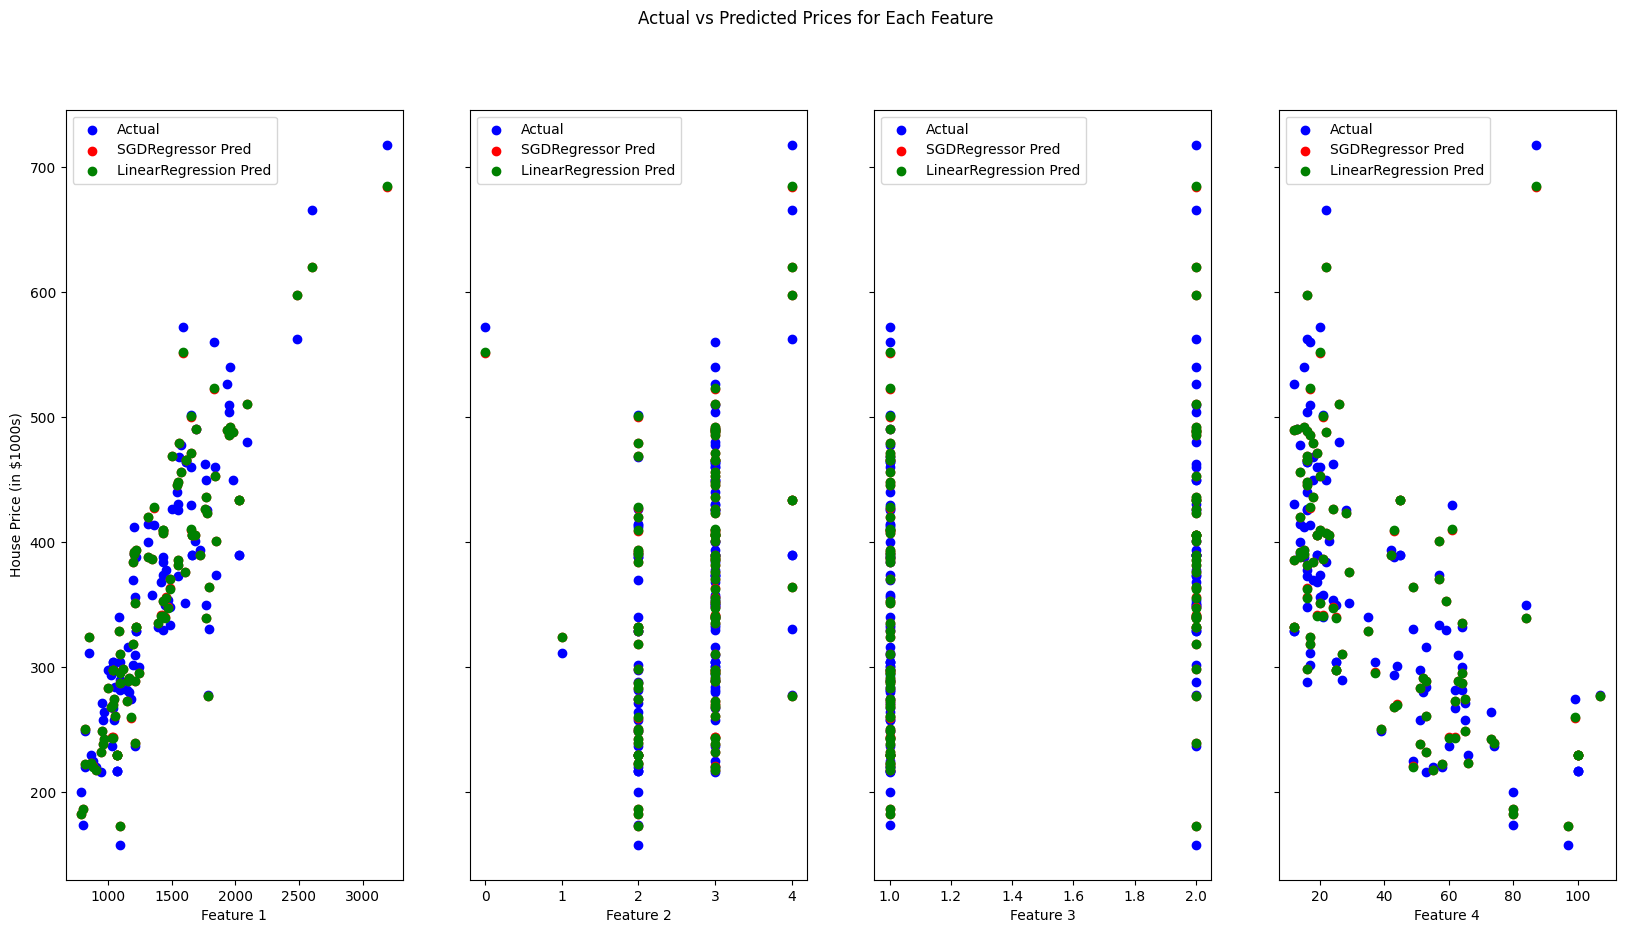

In [33]:
X_features = ['size(sqft)', 'bedrooms', 'floors', 'age']

fig, ax = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for i in range(4):
    ax[i].scatter(X_train[:, i], y_train, color='blue', label='Actual', alpha=0.5)
    ax[i].scatter(X_train[:, i], y_pred_sgd, color='red', label='SGD', alpha=0.5)
    ax[i].scatter(X_train[:, i], y_pred_lin, color='green', label='LR', alpha=0.5, marker='^')
    ax[i].set_xlabel(X_features[i])

ax[0].set_ylabel("Price (1000s)")
ax[0].legend()
fig.suptitle("Actual vs Predicted — SGD (red) & LinearRegression (green)")
plt.tight_layout()
plt.show()

## 9. Model Evaluation & Summary
Compare both methods using R² Score and RMSE.

In [34]:
# R² Score
r2_sgd = sgdr.score(X_scaled, y_train)
r2_lin = linear_reg.score(X_train, y_train)

# RMSE
rmse_sgd = np.sqrt(np.mean((y_pred_sgd - y_train)**2))
rmse_lin = np.sqrt(np.mean((y_pred_lin - y_train)**2))

print("=" * 55)
print(f"{'Metric':<25} {'SGDRegressor':>12} {'LinearReg':>12}")
print("=" * 55)
print(f"{'R² Score':<25} {r2_sgd:>12.4f} {r2_lin:>12.4f}")
print(f"{'RMSE ($1000s)':<25} {rmse_sgd:>12.2f} {rmse_lin:>12.2f}")
print(f"{'New house prediction':<25} ${sgd_price[0]*1000:>10,.2f} ${lr_price[0]*1000:>10,.2f}")
print("=" * 55)

_________________________Summary of Model Comparison:_______________________________-
SGDRegressor - Coefficients: [110.33693986 -21.32361621 -32.48596787 -37.8533131 ], Intercept: [362.25963188]
LinearRegression - Coefficients: [  0.26836643 -32.90362407 -67.28804158  -1.46516763], Intercept: 221.50226366888356
SGDRegressor - First 5 Predictions: [248.61053574 295.57139022 485.83112816 389.70178941 491.97954741]
LinearRegression - First 5 Predictions: [248.65591798 295.58045873 485.81689524 389.61035726 491.96762765]
Actual Target Values: [271.5 300.  509.8 394.  540. ]
SGDRegressor - Prediction for new house: $319025.61
LinearRegression - Prediction for new house: $318936.36
